# Telco Customer Churn: Data Cleaning, Preprocessing Pipeline and Baseline Models

**Owner:** Tân (Lead Pipeline & Baseline) · **Course:** Statistical Learning · **Dataset:** Telco Customer Churn (7,043 customers, 21 columns)

This notebook covers Tân's code tasks. Everything the other two members depend on is defined in `src/churn_core.py` and saved to `data/processed/` and `artifacts/`.

| Task | Section | Output used by teammates |
|---|---|---|
| 1.1 Initial data cleaning | 2 and 3 | `clean_customers()` in `churn_core.py` |
| 1.2 Stratified 80/20 split | 4 | `train.csv`, `test.csv`, `split_train_test()` |
| 1.3 Preprocessing pipeline | 5 | `build_preprocessor()`, `build_model_pipeline()` |
| 1.4 Baseline models | 6 | `baseline_results.csv` |
| 2.1 GridSearch for Logistic Regression and KNN | 7 | `best_logreg_pipeline.joblib`, `best_knn_pipeline.joblib` |
| 2.2 Regression coefficients and odds ratios | 8 | `logreg_coefficients.csv`, odds-ratio figure |

Run with **Kernel → Restart & Run All**. The notebook finds the project root automatically, so it works from either the project folder or `notebooks/`.

## 1. Setup

In [1]:
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier

project_root = next(
    folder for folder in [Path.cwd(), *Path.cwd().parents]
    if (folder / "src" / "churn_core.py").exists()
)
sys.path.append(str(project_root / "src"))
import churn_core as core

for folder in (core.PROCESSED_DIR, core.ARTIFACTS_DIR, core.FIGURES_DIR):
    folder.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.4f}".format)

## 2. Load and audit the raw data

The raw file is loaded untouched first. The audit looks for problems that `isna()` alone cannot see: blank strings, duplicates, inconsistent labels and impossible values. Each finding either justifies a cleaning rule or is recorded as "checked, nothing to do".

In [2]:
customers_raw = core.load_raw_customers()
print(f"Rows: {customers_raw.shape[0]:,} | Columns: {customers_raw.shape[1]}")
customers_raw.head()

Rows: 7,043 | Columns: 21


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.8500,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.9500,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.8500,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.3000,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.7000,151.65,Yes


In [3]:
customers_raw.dtypes.to_frame("raw_dtype").T

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
raw_dtype,str,str,int64,str,str,int64,str,str,str,str,str,str,str,str,str,str,str,str,float64,str,str


`TotalCharges` is stored as text although it holds money amounts, so it must contain at least one non-numeric entry. The next cell counts missing values in two ways: real `NaN` and blank text.

In [4]:
text_columns = customers_raw.select_dtypes(exclude="number")
missing_overview = pd.DataFrame({
    "nan_count": customers_raw.isna().sum(),
    "blank_text_count": text_columns.apply(lambda column: column.str.strip().eq("").sum()),
}).fillna(0).astype(int)
missing_overview[missing_overview.sum(axis=1) > 0]

,nan_count,blank_text_count
TotalCharges,0,11


`isna()` reports no missing values, yet 11 `TotalCharges` cells are blank text. Here are those customers.

In [5]:
blank_total_charges = customers_raw[customers_raw["TotalCharges"].str.strip().eq("")]
display(blank_total_charges[["tenure", "MonthlyCharges", "TotalCharges", "Contract", "Churn"]])

print("Every blank row has tenure == 0:", blank_total_charges["tenure"].eq(0).all())
print("Rows with tenure == 0 in the whole dataset:", customers_raw["tenure"].eq(0).sum())
print("Churn labels among blank rows:", blank_total_charges["Churn"].value_counts().to_dict())

,tenure,MonthlyCharges,TotalCharges,Contract,Churn
488,0,52.5500,,Two year,No
753,0,20.2500,,Two year,No
936,0,80.8500,,Two year,No
1082,0,25.7500,,Two year,No
1340,0,56.0500,,Two year,No
3331,0,19.8500,,Two year,No
3826,0,25.3500,,Two year,No
4380,0,20.0000,,Two year,No
5218,0,19.7000,,One year,No
6670,0,73.3500,,Two year,No


Every blank row has tenure == 0: True
Rows with tenure == 0 in the whole dataset: 11
Churn labels among blank rows: {'No': 11}


**Finding.** The 11 blank cells are exactly the 11 customers with `tenure == 0`. They have just signed up and have not received a first bill, so the true total charged is 0. Setting `TotalCharges = 0` is therefore a factual correction rather than an estimate, and it needs no statistics from the data. That is why it is safe to apply before the train/test split.

In [6]:
duplicated_ids = customers_raw["customerID"].duplicated().sum()
rows_identical_except_id = customers_raw.drop(columns="customerID").duplicated().sum()
print("Duplicated customerID:", duplicated_ids)
print("Rows identical in every column except customerID:", rows_identical_except_id)

Duplicated customerID: 0
Rows identical in every column except customerID: 22


Customer IDs are unique, so no customer appears twice. A small number of different customers share an identical profile, which is expected when 16 of 19 features are categorical. These rows are kept.

In [7]:
for column in core.CATEGORICAL_FEATURES:
    print(f"{column:<18}", sorted(customers_raw[column].unique()))
customers_raw[["tenure", "MonthlyCharges"]].describe()

gender             ['Female', 'Male']
SeniorCitizen      [np.int64(0), np.int64(1)]
Partner            ['No', 'Yes']
Dependents         ['No', 'Yes']
PhoneService       ['No', 'Yes']
MultipleLines      ['No', 'No phone service', 'Yes']
InternetService    ['DSL', 'Fiber optic', 'No']
OnlineSecurity     ['No', 'No internet service', 'Yes']
OnlineBackup       ['No', 'No internet service', 'Yes']
DeviceProtection   ['No', 'No internet service', 'Yes']
TechSupport        ['No', 'No internet service', 'Yes']
StreamingTV        ['No', 'No internet service', 'Yes']
StreamingMovies    ['No', 'No internet service', 'Yes']
Contract           ['Month-to-month', 'One year', 'Two year']
PaperlessBilling   ['No', 'Yes']
PaymentMethod      ['Bank transfer (automatic)', 'Credit card (automatic)', 'Electronic check', 'Mailed check']


,tenure,MonthlyCharges
count,7043.0000,7043.0000
mean,32.3711,64.7617
std,24.5595,30.0900
min,0.0000,18.2500
25%,9.0000,35.5000
50%,29.0000,70.3500
75%,55.0000,89.8500
max,72.0000,118.7500


Labels are spelled consistently (no case or spacing variants), `SeniorCitizen` is strictly 0/1, `tenure` is within 0 to 72 months and `MonthlyCharges` is positive. The last structural check confirms that the "No internet service" and "No phone service" labels appear exactly when they logically must. If they do, they carry no information beyond `InternetService == "No"` and `PhoneService == "No"`.

In [8]:
internet_dependent_columns = [
    "OnlineSecurity", "OnlineBackup", "DeviceProtection",
    "TechSupport", "StreamingTV", "StreamingMovies",
]
has_no_internet = customers_raw["InternetService"].eq("No")
has_no_phone = customers_raw["PhoneService"].eq("No")

consistency_checks = {
    f"{column}: 'No internet service' iff InternetService == 'No'":
        customers_raw[column].eq("No internet service").equals(has_no_internet)
    for column in internet_dependent_columns
}
consistency_checks["MultipleLines: 'No phone service' iff PhoneService == 'No'"] = (
    customers_raw["MultipleLines"].eq("No phone service").equals(has_no_phone)
)
consistency_checks["SeniorCitizen only contains 0 and 1"] = set(customers_raw["SeniorCitizen"]) == {0, 1}
consistency_checks["tenure within 0..72"] = customers_raw["tenure"].between(0, 72).all()
consistency_checks["MonthlyCharges > 0"] = customers_raw["MonthlyCharges"].gt(0).all()

pd.Series(consistency_checks, name="passed").to_frame()

,passed
OnlineSecurity: 'No internet service' iff InternetService == 'No',True
OnlineBackup: 'No internet service' iff InternetService == 'No',True
DeviceProtection: 'No internet service' iff InternetService == 'No',True
TechSupport: 'No internet service' iff InternetService == 'No',True
StreamingTV: 'No internet service' iff InternetService == 'No',True
StreamingMovies: 'No internet service' iff InternetService == 'No',True
MultipleLines: 'No phone service' iff PhoneService == 'No',True
SeniorCitizen only contains 0 and 1,True
tenure within 0..72,True
MonthlyCharges > 0,True


In [9]:
assert all(consistency_checks.values())

total_charges_numeric = pd.to_numeric(customers_raw["TotalCharges"], errors="coerce")
billed_customers = customers_raw["tenure"].gt(0)
expected_total = customers_raw["tenure"] * customers_raw["MonthlyCharges"]
relative_gap = ((total_charges_numeric - expected_total).abs() / expected_total)[billed_customers]
relative_gap.describe(percentiles=[0.5, 0.95]).to_frame("|TotalCharges - tenure x MonthlyCharges| / expected")

,|TotalCharges - tenure x MonthlyCharges| / expected
count,7032.0000
mean,0.0320
std,0.0399
min,0.0000
50%,0.0200
95%,0.1032
max,0.5735


`TotalCharges` is close to `tenure × MonthlyCharges` for most customers (median gap about 2%), with larger gaps for customers whose price changed over time. This means `TotalCharges` is largely a product of the other two numeric features, so strong correlation among them is expected. It matters later when coefficients are interpreted.

## 3. Task 1.1: Clean the data

`clean_customers()` (in `src/churn_core.py`) performs four steps:

1. Strip stray whitespace from text columns.
2. Convert `TotalCharges` to `float` and fill the 11 blanks with 0.
3. Merge "No internet service" and "No phone service" into "No" in the 7 dependent service columns. The audit proved these labels only repeat `InternetService == "No"` and `PhoneService == "No"`. Left in place, the six internet-service columns would become identical dummy columns, and a regression would split their effect between them arbitrarily.
4. Use `customerID` as the row index, so any row can be traced back to a customer (needed later for SHAP waterfall plots).

The function raises an error if the blank cells stop matching `tenure == 0` or if a redundant label is not fully implied by another column, so a changed dataset cannot be cleaned silently.

In [10]:
customers = core.clean_customers(customers_raw)

assert len(customers) == len(customers_raw)
assert customers["TotalCharges"].dtype == "float64"
assert customers.isna().sum().sum() == 0
assert customers.loc[customers["tenure"].eq(0), "TotalCharges"].eq(0).all()
assert all(customers[column].nunique() == 2 for column in core.INTERNET_DEPENDENT_FEATURES + ["MultipleLines"])

cleaning_summary = pd.DataFrame({
    "before": {
        "TotalCharges dtype": str(customers_raw["TotalCharges"].dtype),
        "blank TotalCharges cells": int(customers_raw["TotalCharges"].str.strip().eq("").sum()),
        "rows": len(customers_raw),
        "labels in OnlineSecurity": customers_raw["OnlineSecurity"].nunique(),
    },
    "after": {
        "TotalCharges dtype": str(customers["TotalCharges"].dtype),
        "blank TotalCharges cells": int(customers["TotalCharges"].isna().sum()),
        "rows": len(customers),
        "labels in OnlineSecurity": customers["OnlineSecurity"].nunique(),
    },
})
cleaning_summary

,before,after
TotalCharges dtype,str,float64
blank TotalCharges cells,11,0
rows,7043,7043
labels in OnlineSecurity,3,2


In [11]:
customers[core.NUMERIC_FEATURES].describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.0000,7043.0000,7043.0000
mean,32.3711,64.7617,2279.7343
std,24.5595,30.0900,2266.7945
min,0.0000,18.2500,0.0000
25%,9.0000,35.5000,398.5500
50%,29.0000,70.3500,1394.5500
75%,55.0000,89.8500,3786.6000
max,72.0000,118.7500,8684.8000


In [12]:
customers[core.NUMERIC_FEATURES].corr().round(3)

,tenure,MonthlyCharges,TotalCharges
tenure,1.0000,0.2480,0.8260
MonthlyCharges,0.2480,1.0000,0.6510
TotalCharges,0.8260,0.6510,1.0000


`TotalCharges` correlates strongly with `tenure` (about 0.83), as the audit predicted. The target is also checked here because it decides how the split must be done.

In [13]:
churn_share = customers[core.TARGET_COLUMN].value_counts(normalize=True)
churn_share.to_frame("share")

,share
Churn,
No,0.7346
Yes,0.2654


Only about 26.5% of customers churn, so a random split could easily shift this ratio. The split therefore has to be stratified.

## 4. Task 1.2: Stratified train/test split

The split uses `test_size=0.20`, `stratify=y` and `random_state=42`. These values live in `churn_core.py` as `TEST_SIZE` and `RANDOM_STATE`, so all three members get the identical split by calling `split_train_test()`.

In [14]:
X_train, X_test, y_train, y_test = core.split_train_test(customers)

split_overview = pd.DataFrame(
    {"rows": [len(y_train), len(y_test)], "churn_rate": [y_train.mean(), y_test.mean()]},
    index=["train", "test"],
)
assert set(X_train.index).isdisjoint(X_test.index)
assert abs(y_train.mean() - y_test.mean()) < 0.001
split_overview

,rows,churn_rate
train,5634,0.2654
test,1409,0.2654


In [15]:
X_train.join(y_train).to_csv(core.PROCESSED_DIR / "train.csv")
X_test.join(y_test).to_csv(core.PROCESSED_DIR / "test.csv")

## 5. Task 1.3: Scikit-Learn preprocessing pipeline

`build_preprocessor()` returns an **unfitted** `ColumnTransformer`:

- `tenure`, `MonthlyCharges`, `TotalCharges` → `StandardScaler`
- the 16 categorical columns → `OneHotEncoder(drop="first")`. The first category (alphabetical) of every column is dropped and becomes the **reference category**, so a binary column turns into one 0/1 column and a three-level column into two. Without a reference, the dummy columns of one variable always sum to 1 and regression coefficients have no clear meaning. Unseen categories at prediction time are encoded as the reference instead of raising an error.

`SeniorCitizen` is already 0/1 but describes a category, so it goes through the encoder with the other binary columns.

In [16]:
preprocessor = core.build_preprocessor()
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('categorical', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_na

**Anti-leakage rule.** `fit` runs on the training set only. The test set only goes through `transform`, using the means, standard deviations and category lists learned from training data.

In [17]:
X_train_encoded = preprocessor.fit_transform(X_train)
X_test_encoded = preprocessor.transform(X_test)

print("Train:", X_train.shape, "->", X_train_encoded.shape)
print("Test: ", X_test.shape, "->", X_test_encoded.shape)

assert list(X_train_encoded.columns) == list(X_test_encoded.columns)
assert not X_train_encoded.isna().any().any()
assert not X_test_encoded.isna().any().any()

Train: (5634, 19) -> (5634, 23)
Test:  (1409, 19) -> (1409, 23)


In [18]:
fitted_scaler = preprocessor.named_transformers_["numeric"]
assert np.allclose(fitted_scaler.mean_, X_train[core.NUMERIC_FEATURES].mean())

scaling_check = pd.DataFrame({
    "train_mean": X_train_encoded[core.NUMERIC_FEATURES].mean(),
    "train_std": X_train_encoded[core.NUMERIC_FEATURES].std(ddof=0),
    "test_mean": X_test_encoded[core.NUMERIC_FEATURES].mean(),
    "test_std": X_test_encoded[core.NUMERIC_FEATURES].std(ddof=0),
})
scaling_check

,train_mean,train_std,test_mean,test_std
tenure,-0.0000,1.0000,-0.0232,0.9980
MonthlyCharges,-0.0000,1.0000,-0.0279,0.9918
TotalCharges,0.0000,1.0000,-0.0430,0.9718


The training columns have mean 0 and standard deviation 1 by construction. The test columns do not, and that is the proof that the scaler never saw test data: its statistics came from the training set only. The scaler's learned means match the training means exactly (checked by the `assert`).

In [19]:
encoded_feature_names = list(X_train_encoded.columns)
print(f"{len(encoded_feature_names)} model input columns")
encoded_feature_names

23 model input columns


['tenure',
 'MonthlyCharges',
 'TotalCharges',
 'gender_Male',
 'SeniorCitizen_1',
 'Partner_Yes',
 'Dependents_Yes',
 'PhoneService_Yes',
 'MultipleLines_Yes',
 'InternetService_Fiber optic',
 'InternetService_No',
 'OnlineSecurity_Yes',
 'OnlineBackup_Yes',
 'DeviceProtection_Yes',
 'TechSupport_Yes',
 'StreamingTV_Yes',
 'StreamingMovies_Yes',
 'Contract_One year',
 'Contract_Two year',
 'PaperlessBilling_Yes',
 'PaymentMethod_Credit card (automatic)',
 'PaymentMethod_Electronic check',
 'PaymentMethod_Mailed check']

Reference category dropped for each categorical column (every dummy column is read against it):

In [20]:
fitted_encoder = preprocessor.named_transformers_["categorical"]
reference_categories = pd.Series(
    {column: fitted_encoder.categories_[position][fitted_encoder.drop_idx_[position]]
     for position, column in enumerate(core.CATEGORICAL_FEATURES)},
    name="reference_category",
)
reference_categories.to_frame()

,reference_category
gender,Female
SeniorCitizen,0
Partner,No
Dependents,No
PhoneService,No
MultipleLines,No
InternetService,DSL
OnlineSecurity,No
OnlineBackup,No
DeviceProtection,No


## 6. Task 1.4: Baseline models

Four baselines, each wrapped in the same pipeline so preprocessing is learned from the training data only:

- **Dummy** (always predicts the majority class), the floor that any real model must beat
- **Logistic Regression** with L1 and with L2 penalty (default `C=1`)
- **KNN** with `k=5`

Precision, recall and F1 are for the churn class (label 1). The table shows train and test side by side so that overfitting is visible.

In [21]:
baseline_models = {
    "Dummy (most frequent)": DummyClassifier(strategy="most_frequent"),
    "Logistic Regression (L1)": core.make_logistic_regression("l1"),
    "Logistic Regression (L2)": core.make_logistic_regression("l2"),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
}
datasets = {"train": (X_train, y_train), "test": (X_test, y_test)}

baseline_rows = []
for model_name, estimator in baseline_models.items():
    model_pipeline = core.build_model_pipeline(estimator).fit(X_train, y_train)
    for split_name, (features, target) in datasets.items():
        metrics = core.compute_basic_metrics(target, model_pipeline.predict(features))
        baseline_rows.append({"model": model_name, "split": split_name, **metrics})

baseline_results = pd.DataFrame(baseline_rows)
baseline_results.to_csv(core.ARTIFACTS_DIR / "baseline_results.csv", index=False)
baseline_results.set_index(["model", "split"])

accuracy  precision  recall     f1
model                    split                                    
Dummy (most frequent)    train    0.7346     0.0000  0.0000 0.0000
                         test     0.7346     0.0000  0.0000 0.0000
Logistic Regression (L1) train    0.8051     0.6584  0.5518 0.6004
                         test     0.8027     0.6509  0.5535 0.5983
Logistic Regression (L2) train    0.8049     0.6584  0.5505 0.5996
                         test     0.8027     0.6509  0.5535 0.5983
KNN (k=5)                train    0.8344     0.7081  0.6395 0.6721
                         test     0.7630     0.5538  0.5508 0.5523

The Dummy model reaches about 73.5% accuracy with zero recall: accuracy alone is misleading on an imbalanced target, which is why recall and F1 on the churn class are reported. KNN fits the training set much better than the test set, while both logistic regressions show a small train/test gap.

## 7. Task 2.1: GridSearch tuning for Logistic Regression and KNN

Each candidate is a full pipeline, so the scaler and encoder are re-fitted inside every cross-validation fold. Folds are `StratifiedKFold(5, shuffle=True, random_state=42)`. Models are ranked by mean F1 of the churn class, with ROC-AUC recorded alongside (the two metrics Yến's comparison table uses).

- Logistic Regression: `C` from 0.001 to 1000, one search per penalty (L1 and L2)
- KNN: number of neighbours and distance metric

The test set is not used for selection. Test scores are shown once at the end for reporting.

In [22]:
cv_splitter = StratifiedKFold(n_splits=core.N_CV_FOLDS, shuffle=True, random_state=core.RANDOM_STATE)


def run_grid_search(estimator, param_grid):
    search = GridSearchCV(
        core.build_model_pipeline(estimator),
        param_grid=param_grid,
        scoring={"f1": "f1", "roc_auc": "roc_auc"},
        refit="f1",
        cv=cv_splitter,
        n_jobs=-1,
    )
    return search.fit(X_train, y_train)


def describe_search(search, model_name):
    best = search.best_index_
    results = search.cv_results_
    return {
        "model": model_name,
        "best_params": {name.replace("model__", ""): value for name, value in search.best_params_.items()},
        "cv_f1_mean": results["mean_test_f1"][best],
        "cv_f1_std": results["std_test_f1"][best],
        "cv_roc_auc_mean": results["mean_test_roc_auc"][best],
        "cv_roc_auc_std": results["std_test_roc_auc"][best],
    }

In [23]:
logreg_param_grid = {"model__C": [0.001, 0.01, 0.1, 1, 10, 100, 1000]}
logreg_searches = {
    penalty: run_grid_search(core.make_logistic_regression(penalty), logreg_param_grid)
    for penalty in ("l1", "l2")
}
pd.DataFrame([
    describe_search(search, f"Logistic Regression ({penalty.upper()})")
    for penalty, search in logreg_searches.items()
])

,model,best_params,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std
0,Logistic Regression (L1),{'C': 100},0.5974,0.0288,0.8463,0.0129
1,Logistic Regression (L2),{'C': 100},0.5974,0.0288,0.8463,0.0129


In [24]:
best_logreg_penalty = max(logreg_searches, key=lambda penalty: logreg_searches[penalty].best_score_)
best_logreg_search = logreg_searches[best_logreg_penalty]
print("Selected penalty:", best_logreg_penalty.upper(), "| C =", best_logreg_search.best_params_["model__C"])

Selected penalty: L1 | C = 100


In [25]:
knn_param_grid = {
    "model__n_neighbors": [3, 5, 7, 9, 11, 15, 21, 31, 41, 51, 61, 81],
    "model__metric": ["euclidean", "manhattan"],
}
best_knn_search = run_grid_search(KNeighborsClassifier(), knn_param_grid)

knn_grid_results = pd.DataFrame(best_knn_search.cv_results_).sort_values("rank_test_f1")
knn_grid_results[["param_model__n_neighbors", "param_model__metric",
                  "mean_test_f1", "std_test_f1", "mean_test_roc_auc"]].head(5)

,param_model__n_neighbors,param_model__metric,mean_test_f1,std_test_f1,mean_test_roc_auc
20,41,manhattan,0.6054,0.0180,0.8375
7,31,euclidean,0.6001,0.0202,0.8356
8,41,euclidean,0.5993,0.0161,0.8362
22,61,manhattan,0.5984,0.0153,0.8391
21,51,manhattan,0.5983,0.0223,0.8382


In [26]:
logreg_grid_results = pd.concat(
    [pd.DataFrame(search.cv_results_).assign(penalty=penalty) for penalty, search in logreg_searches.items()]
)
logreg_grid_results.to_csv(core.ARTIFACTS_DIR / "gridsearch_logreg_results.csv", index=False)
knn_grid_results.to_csv(core.ARTIFACTS_DIR / "gridsearch_knn_results.csv", index=False)

best_logreg_pipeline = best_logreg_search.best_estimator_
best_knn_pipeline = best_knn_search.best_estimator_
joblib.dump(best_logreg_pipeline, core.ARTIFACTS_DIR / "best_logreg_pipeline.joblib")
joblib.dump(best_knn_pipeline, core.ARTIFACTS_DIR / "best_knn_pipeline.joblib")

tuning_summary = pd.DataFrame([
    describe_search(best_logreg_search, f"Logistic Regression ({best_logreg_penalty.upper()}), tuned"),
    describe_search(best_knn_search, "KNN, tuned"),
])
for row, pipeline in zip(tuning_summary.index, (best_logreg_pipeline, best_knn_pipeline)):
    test_metrics = core.compute_basic_metrics(y_test, pipeline.predict(X_test))
    for metric_name, value in test_metrics.items():
        tuning_summary.loc[row, f"test_{metric_name}"] = value
tuning_summary.to_csv(core.ARTIFACTS_DIR / "tuning_summary.csv", index=False)
tuning_summary

,model,best_params,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,test_accuracy,test_precision,test_recall,test_f1
0,"Logistic Regression (L1), tuned",{'C': 100},0.5974,0.0288,0.8463,0.0129,0.8020,0.6498,0.5508,0.5962
1,"KNN, tuned","{'metric': 'manhattan', 'n_neighbors': 41}",0.6054,0.0180,0.8375,0.0087,0.7899,0.6089,0.5829,0.5956


Cross-validated F1 (mean and standard deviation over 5 folds) is the figure to compare across models. The `test_*` columns are a single reporting pass and were not used to choose any parameter. The final evaluation of the champion model belongs to NMinh's Task 2.6.

## 8. Task 2.2: Regression coefficients and odds ratios

The coefficient $\beta_j$ is the change in the log-odds of churn when feature $j$ increases by one unit, holding the others fixed. The odds ratio is $e^{\beta_j}$. Reading rules for this model:

- **Numeric features** were standardised, so their odds ratio is per **one standard deviation** increase.
- **Dummy features** compare the category shown against the reference category of its column (table in Section 5). For example `Contract_Two year` is read against month-to-month contracts, and `InternetService_Fiber optic` against DSL.
- An odds ratio above 1 raises churn odds, below 1 lowers them. A coefficient of exactly 0 means the L1 penalty removed the feature.

In [27]:
logreg_model = best_logreg_pipeline.named_steps["model"]
coefficient_table = pd.DataFrame({
    "feature": core.get_feature_names(best_logreg_pipeline),
    "coefficient_beta": logreg_model.coef_.ravel(),
})
coefficient_table["odds_ratio"] = np.exp(coefficient_table["coefficient_beta"])
coefficient_table["effect_on_churn"] = np.select(
    [coefficient_table["coefficient_beta"] > 0, coefficient_table["coefficient_beta"] < 0],
    ["raises odds", "lowers odds"],
    default="removed by L1",
)
coefficient_table = coefficient_table.sort_values("coefficient_beta", ascending=False).reset_index(drop=True)
coefficient_table.to_csv(core.ARTIFACTS_DIR / "logreg_coefficients.csv", index=False)

print(f"Model: Logistic Regression ({best_logreg_penalty.upper()}), C = {best_logreg_search.best_params_['model__C']}")
print(f"Intercept: {logreg_model.intercept_[0]:.4f}")
print(f"Features removed by the penalty: {(coefficient_table['coefficient_beta'] == 0).sum()} of {len(coefficient_table)}")
coefficient_table

Model: Logistic Regression (L1), C = 100
Intercept: -4.2411
Features removed by the penalty: 0 of 23


,feature,coefficient_beta,odds_ratio,effect_on_churn
0,InternetService_Fiber optic,2.6911,14.7486,raises odds
1,StreamingMovies_Yes,0.9767,2.6557,raises odds
2,StreamingTV_Yes,0.9756,2.6528,raises odds
3,PhoneService_Yes,0.9395,2.5587,raises odds
4,MultipleLines_Yes,0.6638,1.9422,raises odds
5,TotalCharges,0.5844,1.7939,raises odds
6,PaymentMethod_Electronic check,0.3831,1.4669,raises odds
7,PaperlessBilling_Yes,0.3689,1.4461,raises odds
8,DeviceProtection_Yes,0.3349,1.3978,raises odds
9,OnlineBackup_Yes,0.1960,1.2166,raises odds


In [28]:
fitted_scaler = best_logreg_pipeline.named_steps["preprocess"].named_transformers_["numeric"]
numeric_interpretation = pd.DataFrame({
    "std_in_training_data": fitted_scaler.scale_,
}, index=core.NUMERIC_FEATURES).join(
    coefficient_table.set_index("feature")[["coefficient_beta", "odds_ratio"]]
).rename(columns={"odds_ratio": "odds_ratio_per_+1_std"})
numeric_interpretation

,std_in_training_data,coefficient_beta,odds_ratio_per_+1_std
tenure,24.5666,-1.3060,0.2709
MonthlyCharges,30.1354,-2.2919,0.1011
TotalCharges,2279.0020,0.5844,1.7939


Multicollinearity check. The variance inflation factor (VIF) of a feature measures how well the other features predict it; values above about 10 signal that its coefficient is unstable.

In [29]:
def variance_inflation_factors(design_matrix):
    values = design_matrix.to_numpy(dtype=float)
    factors = {}
    for position, name in enumerate(design_matrix.columns):
        target = values[:, position]
        others = np.column_stack([np.ones(len(values)), np.delete(values, position, axis=1)])
        fitted = others @ np.linalg.lstsq(others, target, rcond=None)[0]
        r_squared = 1 - ((target - fitted) ** 2).sum() / ((target - target.mean()) ** 2).sum()
        factors[name] = 1 / (1 - r_squared)
    return pd.Series(factors, name="vif").sort_values(ascending=False)


variance_inflation_factors(X_train_encoded).head(8).to_frame()

,vif
MonthlyCharges,861.9108
InternetService_Fiber optic,147.7881
InternetService_No,103.0850
PhoneService_Yes,35.3007
StreamingTV_Yes,24.0338
StreamingMovies_Yes,24.0145
TotalCharges,10.9952
tenure,7.6412


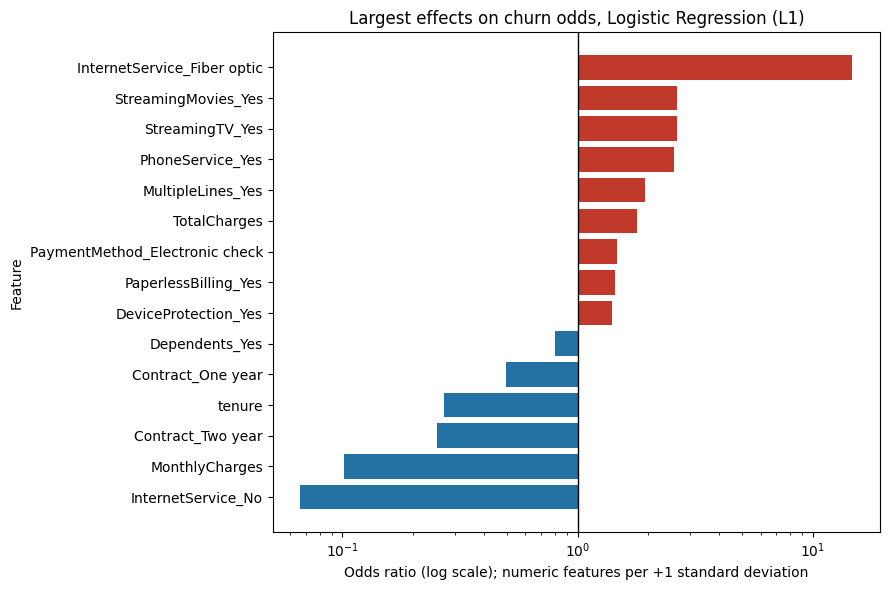

In [30]:
features_to_plot = 15
largest_effects = coefficient_table.reindex(
    coefficient_table["coefficient_beta"].abs().sort_values(ascending=False).index
).head(features_to_plot).sort_values("odds_ratio")

bar_colors = np.where(largest_effects["odds_ratio"] > 1, "#c0392b", "#2471a3")
fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(largest_effects["feature"], largest_effects["odds_ratio"] - 1, left=1, color=bar_colors)
ax.set_xscale("log")
ax.axvline(1, color="black", linewidth=1)
ax.set_xlabel("Odds ratio (log scale); numeric features per +1 standard deviation")
ax.set_ylabel("Feature")
ax.set_title(f"Largest effects on churn odds, Logistic Regression ({best_logreg_penalty.upper()})")
fig.tight_layout()
fig.savefig(core.FIGURES_DIR / "figure_logreg_odds_ratios.png", dpi=200)
plt.show()

Bars to the right of the vertical line (red) raise the odds of churn, bars to the left (blue) lower them. Interpret magnitudes with care: the VIF table shows that `MonthlyCharges`, `TotalCharges` and `tenure` (and the internet-service dummies, which determine most of the monthly price) overlap strongly, so their individual coefficients partly offset one another and should be read together rather than one by one. The coefficients describe association in this dataset, not the effect of changing a customer's contract or services.

## 9. Hand-off check

The cell below reloads what was saved to disk and confirms that teammates will get exactly the same split and the same fitted model.

In [31]:
saved_train = pd.read_csv(core.PROCESSED_DIR / "train.csv", index_col=core.ID_COLUMN)
saved_test = pd.read_csv(core.PROCESSED_DIR / "test.csv", index_col=core.ID_COLUMN)
assert saved_train.index.equals(X_train.index) and saved_test.index.equals(X_test.index)

reloaded_logreg = joblib.load(core.ARTIFACTS_DIR / "best_logreg_pipeline.joblib")
assert (reloaded_logreg.predict(X_test) == best_logreg_pipeline.predict(X_test)).all()

saved_files = sorted(path.name for path in core.ARTIFACTS_DIR.iterdir())
print("artifacts/:", saved_files)
print("data/processed/:", sorted(path.name for path in core.PROCESSED_DIR.iterdir()))

artifacts/: ['baseline_results.csv', 'best_knn_pipeline.joblib', 'best_logreg_pipeline.joblib', 'gridsearch_knn_results.csv', 'gridsearch_logreg_results.csv', 'logreg_coefficients.csv', 'tuning_summary.csv']
data/processed/: ['test.csv', 'train.csv']


| For | What to load | How |
|---|---|---|
| Yến (Tasks 1.5 to 2.5) | Same split, unfitted preprocessing recipe, shared constants | `core.split_train_test(customers)`, `core.build_preprocessor()`, `core.RANDOM_STATE`, `core.N_CV_FOLDS` |
| Yến (SMOTE) | Preprocessor to place inside an `imblearn` pipeline | `ImbPipeline([("preprocess", core.build_preprocessor()), ("smote", SMOTE(random_state=core.RANDOM_STATE)), ("model", ...)])` |
| NMinh (Tasks 1.8 to 2.9) | Cleaned table, test set, tuned models, feature names | `core.clean_customers(core.load_raw_customers())`, `data/processed/test.csv`, `joblib.load("artifacts/best_logreg_pipeline.joblib")`, `core.get_feature_names(pipeline)` |